# Lecture 5

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
unrate = pd.read_csv('UNRATE.csv', parse_dates=['observation_date'],
                     index_col='observation_date')['UNRATE']
usrec = pd.read_csv('USREC.csv', parse_dates=['observation_date'],
                     index_col='observation_date')['USREC']
unrate.tail()

observation_date
2026-04-01    4.3
2026-05-01    4.3
2026-06-01    4.2
2026-07-01    4.1
2026-08-01    4.1
Name: UNRATE, dtype: float64

Above, parse_dates turns the date column into real dates, index_col makes that column the indes for slicing by date, and ['SERIES'] at the end takes the one data column out of the DataFrame, leaving a Series.

unrate.shift(12) slides the column down twelve rows (each months sits next to the same month a year earlier.

In [3]:
chg12 = unrate - unrate.shift(12)
df = pd.DataFrame({'UNRATE': unrate, 'CHG12': chg12, 'USREC': usrec})
df = df.loc['1948':]
df.tail()

,UNRATE,CHG12,USREC
observation_date,,,
2026-04-01,4.3,0.1,0
2026-05-01,4.3,0.0,0
2026-06-01,4.2,0.1,0
2026-07-01,4.1,-0.2,0
2026-08-01,4.1,-0.2,0


In [4]:
#How many rows? What is missing?
print(df.shape)
df.isnull().sum()

(944, 3)


UNRATE     1
CHG12     13
USREC      0
dtype: int64

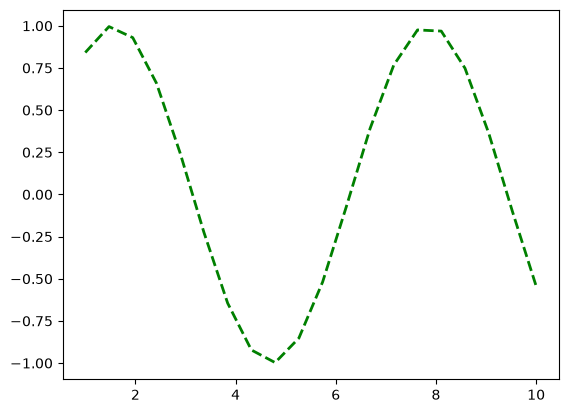

In [5]:
#Creating a chart: set x and y values via numpy array
x = np.linspace(1,10,20)
y=np.sin(x)
plt.plot(x, y, 'g--', linewidth=2)
plt.show()

# 

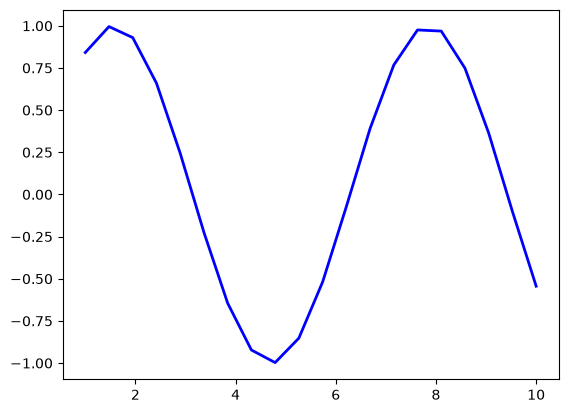

In [6]:
#Alternatively
fig, ax = plt.subplots()
ax.plot(x,y,'b-',linewidth=2)

In [7]:
unrate.head().to_frame()

,UNRATE
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


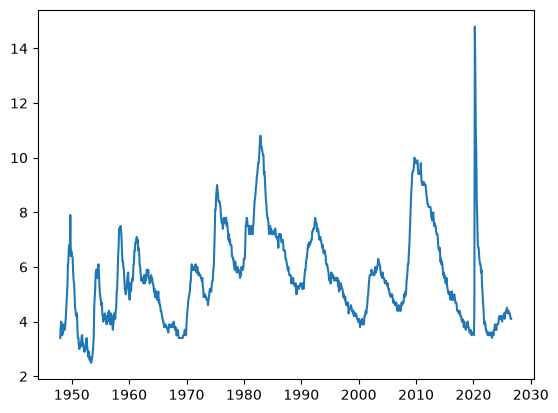

In [8]:
fig, ax = plt.subplots()
ax.plot(df['UNRATE'])
plt.show()

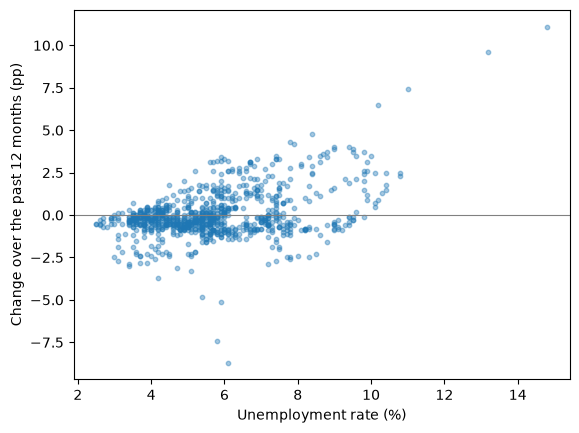

In [9]:
fig, ax = plt.subplots()
ax.scatter(x=df['UNRATE'], y=df['CHG12'], s=10, alpha=0.4)
ax.axhline(0,color='grey',linewidth=0.8)
ax.set_xlabel('Unemployment rate (%)')
ax.set_ylabel('Change over the past 12 months (pp)')
plt.show()

In [10]:
since1950 = df.loc['1950':].copy()
# a column to group on: 1953 -> 1950, 1967 -> 1960, etc.
since1950['decade'] = since1950.index.year // 10*10
avg_unrate = since1950.groupby('decade')['UNRATE'].mean()
avg_unrate

decade
1950    4.511667
1960    4.779167
1970    6.217500
1980    7.272500
1990    5.762500
2000    5.541667
2010    6.220833
2020    4.783544
Name: UNRATE, dtype: float64

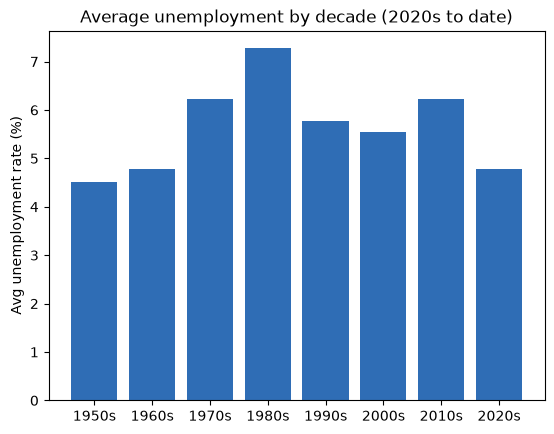

In [12]:
labels = [str(d) + 's' for d in avg_unrate.index]

fig, ax = plt.subplots()
ax.bar(labels, avg_unrate.values, color='#2F6DB5')
ax.set_ylabel('Avg unemployment rate (%)')
ax.set_title('Average unemployment by decade (2020s to date)')
plt.show()

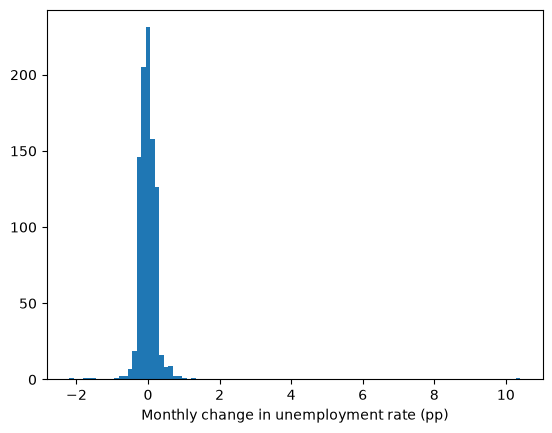

In [13]:
change = df['UNRATE'].diff().dropna()
fig, ax = plt.subplots()
ax.hist(change, bins = 100)
ax.set_xlabel ('Monthly change in unemployment rate (pp)')
plt.show()

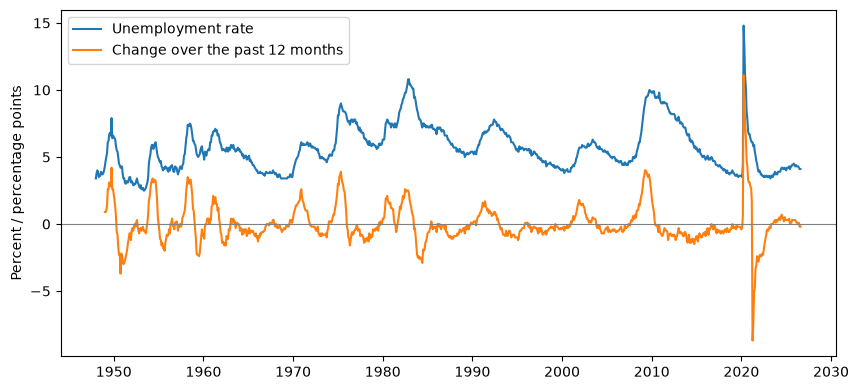

In [14]:
fig, ax = plt.subplots(figsize = (10,4.5))
ax.plot(df['UNRATE'], label='Unemployment rate')
ax.plot(df['CHG12'], label='Change over the past 12 months')
ax.axhline(0, color='grey',linewidth=0.8)
ax.set_ylabel('Percent / percentage points')
ax.legend()
plt.show()